In [160]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Зробити (або знайти) декілька зображень будь-якого об'єкта на однорідному фоні з
рівномірним освітленням. А також зображення фону.
Обрізати зображення через "NumPy Array Slicing"
Конвертувати зображення в чб варіант.
Застосувати метод Отсу для знаходження порогу глобальної бінаризації. Створити
бінарну маску об'єкта на зображенні.
За допомогою отриманої маски, вирізати лише об’єкт з оригінального ображення та
додати його на зображення фону.
Завантажити роботу (код, вхідні зображення та результат) на свій гітхаб. Посилання
на репозиторій а також файл з кодом (.py.ipynb.ccp etc.) додати в Google Classroom
(для звітності).
___

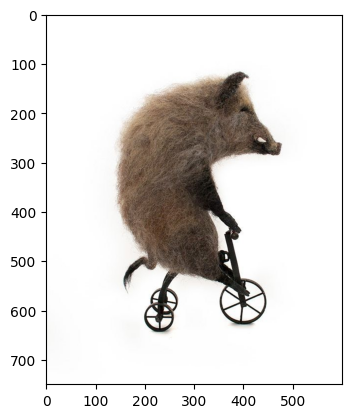

In [161]:
pic_path = 'picts/kaban.png'
#pic_path = 'picts/test.png'
bg_path = 'picts/int.jpg'

pic_raw = plt.imread(pic_path)
bg_raw = plt.imread(bg_path)

plt.imshow(pic_raw)

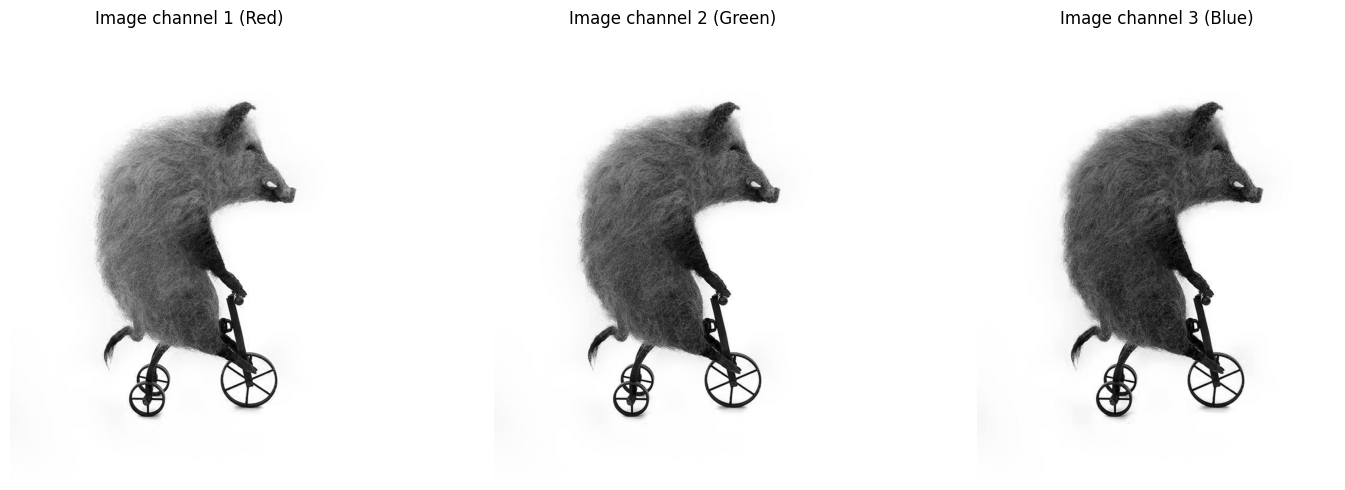

In [162]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for a in axes:
    a.axis('off')

axes[0].imshow(pic_raw[:, :, 0], cmap='gray')
axes[0].set_title(f'Image channel 1 (Red)')

axes[1].imshow(pic_raw[:, :, 1], cmap='gray')
axes[1].set_title(f'Image channel 2 (Green)')

axes[2].imshow(pic_raw[:, :, 2], cmap='gray')
axes[2].set_title('Image channel 3 (Blue)')

plt.tight_layout()
plt.show()

## Обрізаємо зображення та робимо сірим
---

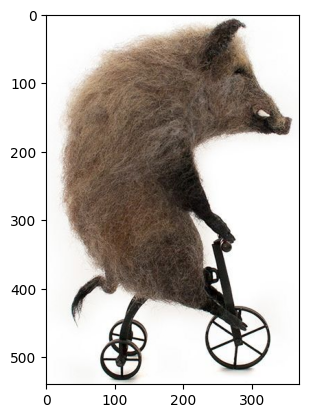

In [163]:
kaban = pic_raw[110:650, 120:490, :]
plt.imshow(kaban, cmap='gray')

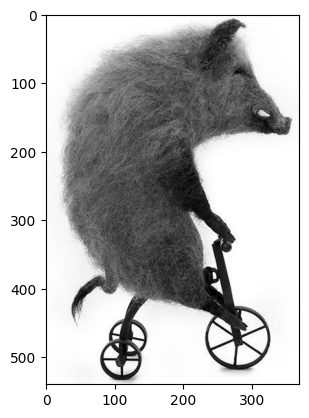

In [164]:
kaban_gray = cv2.cvtColor(kaban, cv2.COLOR_RGB2GRAY)
kaban_gray = (kaban_gray * 255).astype(np.uint8)
plt.imshow(kaban_gray, cmap = "gray")

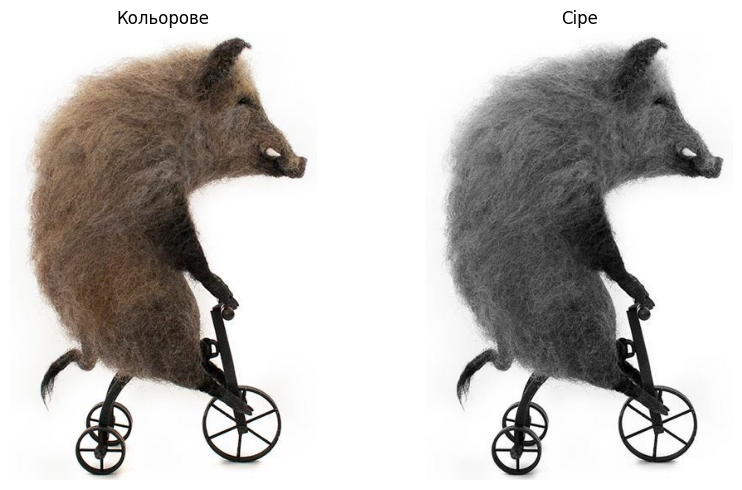

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

axes[0].imshow(kaban)
axes[0].axis('off')
axes[0].set_title("Кольорове")

axes[1].imshow(kaban_gray, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Сіре")
plt.tight_layout()
plt.show()

## Гістограма кабана
___

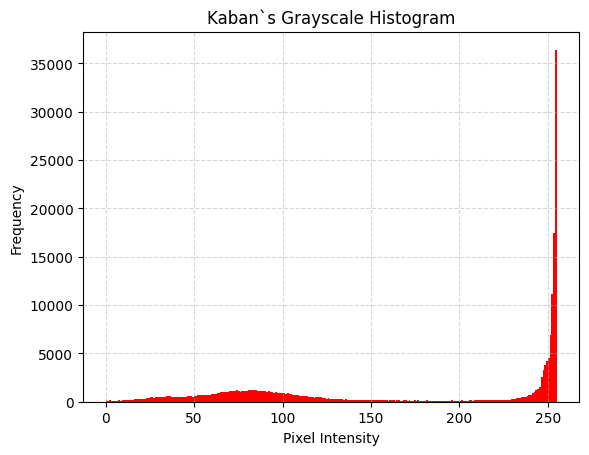

In [166]:
plt.hist(kaban_gray.ravel(), bins=256, range=(0, 255), color='red')
#plt.hist(kaban_gray.ravel(), bins=256, range=(0, 1), color='red')
plt.title('Kaban`s Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [167]:
print(kaban_gray.min(), kaban_gray.max(), kaban_gray.dtype)

0 255 uint8


### Метод отсу (знаходження порогу)
---

In [168]:

hist, bins = np.histogram(kaban_gray.ravel(), bins=256, range=(0, 256))
#hist, bins = np.histogram(kaban_gray.ravel(), bins=256, range=(0, 1))
p = hist / hist.sum() #масив ймовірностей для кожної яскравості
#len(p)
#print(f"{hist.sum()}  , {hist[0]}, {hist[-1]}")


q1 = np.zeros(256)
q2 = np.zeros(256)

#q1 = np.cumsum(p)
#q2 = 1 - q1

u1 = np.zeros(256)
u2 = np.zeros(256)

for t in range(256):
    q1[t] = np.sum(p[:t])
    q2[t] = np.sum(p[t:])
    if q1[t] == 0 or q2[t] == 0:
        continue
    u1[t] = np.sum(np.arange(t) * p[:t]) / q1[t]
    u2[t] = np.sum(np.arange(t, 256) * p[t:]) / q2[t]

#s1 = np.zeros(256)
#s2 = np.zeros(256)
#sb = s1

#for t in range(256):
 #   s1[t] = np.sum((np.arange(t) -u1[t])**2) * p[t] / q1[t] # сігми без квадратів, бо немає сенсу їх знаходити, оскульки в майбутньому все одно буде використовуватись сігма в квадраті 
  #  s2[t] = np.sum((np.arange(t, 256) -u2[t])**2) * p[t] / q2[t]
    
sb = q1 * q2 * (u1 - u2)** 2
#sw = np.zeros(256)
#for t in range(256):
#    sw[t] = q1[t] * s1[t] + q2[t] * s2[t]

t_opt = np.argmax(sb)
print("Оптимальний поріг:", t_opt)

Оптимальний поріг: 163


In [169]:
def binarization(a: np.ndarray, t: float) -> np.ndarray:
    return np.where(a > t, 0, 1).astype(np.uint8)

### Бінаризація та створення маски
---

(540, 370) uint8


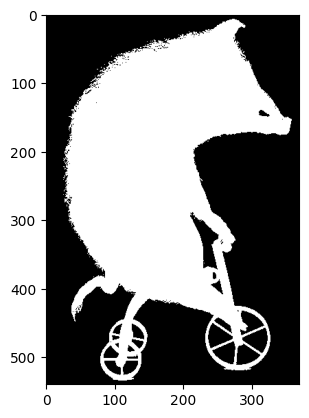

In [170]:

img_mask = binarization(kaban_gray, t_opt)
print(img_mask.shape, img_mask.dtype)
plt.imshow(img_mask, cmap='gray')

### Застосування маски
---

(540, 370, 3) float32
0.0 1.0
0.0 0.74509805


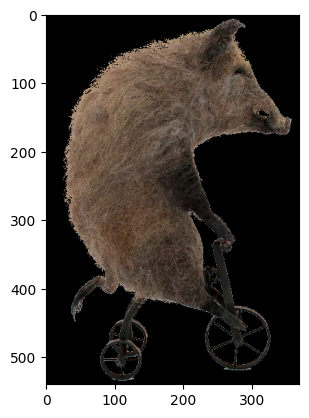

In [171]:

img_separate = np.zeros_like(kaban)
img_separate = kaban * (img_mask[:, :, None] == 1)
plt.imshow(img_separate)
print(img_separate.shape, img_separate.dtype)
print(np.min(kaban), np.max(kaban))
print(np.min(img_separate), np.max(img_separate))

(630, 1200, 3) uint8
0 255


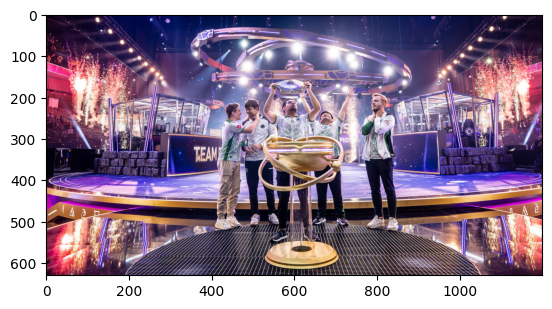

In [172]:
plt.imshow(bg_raw)
print(bg_raw.shape, bg_raw.dtype)
print(np.min(bg_raw), np.max(bg_raw))

## Композиція зображень
----

In [173]:
def compose(bg_img, fg_img, mask, y_pos, x_pos):
    h_fg, w_fg, _ = fg_img.shape
    h_bg, w_bg, _ = bg_img.shape
    
    result = bg_img.copy()

    y_end = min(y_pos + h_fg, h_bg)
    x_end = min(x_pos + w_fg, w_bg)
    
    y_slice = slice(y_pos, y_end)
    x_slice = slice(x_pos, x_end)
    
    h_fit = y_end - y_pos
    w_fit = x_end - x_pos

    

    bg_patch = result[y_slice, x_slice, :3].astype(float) / 255.0 #це робимо, бо якщо подивитись зверху, то у bg np.min та np.max = 0 та 255 відповідно, коли у маски та кабана там флоат
    
    


    fg_patch = fg_img[:h_fit, :w_fit]
    mask_patch = mask[:h_fit, :w_fit] 


    mask_float = mask_patch.astype(float)
    

    if mask_float.ndim == 2:
        mask_float = np.expand_dims(mask_float, axis=-1)


    composed_patch = (fg_patch * (mask_float) + bg_patch * (1-mask_float))

    composed_patch_uint8 = (composed_patch * 255).astype(bg_img.dtype)
    result[y_slice, x_slice] = composed_patch_uint8
    return result

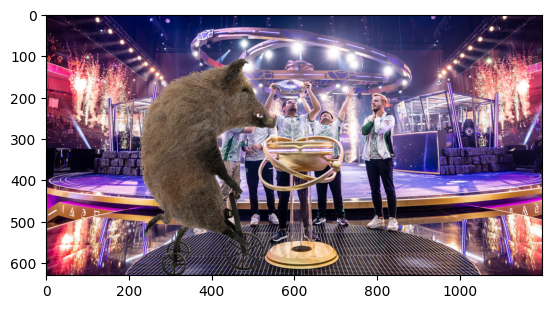

In [174]:
img_res = bg_raw.copy()
x, y = 200, 100
kaban = kaban[:, :, :3]
img_res = compose(bg_raw, kaban, img_mask, y, x)
plt.imshow(img_res)